# Class Result Analysis Project

## Project Objective

The objective of this project is to analyze student academic performance using semester SPI data and derive meaningful insights using Python-based data analytics and visualization techniques.

---

## Data Loading


In [95]:
import pandas as pd

In [96]:
df = pd.read_excel("CLASS_RESULT_PROJECT_DATASET.xlsx")

##### Missing SPI values in certain semesters represent students with due credits/backlogs and were retained for analytical purposes instead of being removed.

In [97]:
df.head()

,S.No,STUDENT NAME,ROLL NO,Gender,SPI - 1st Sem,SPI - 2nd Sem,SPI - 3rd Sem,SPI - 4th Sem,SPI - 5th Sem,SPI - 6th Sem,Attendance,Stay
0,1,Aarti Suryvanshi,23113001,Female,5.95,7.25,6.69,7.26,7.66,7.60,85,Day Scholar
1,2,Aaryan lahre,23113002,Male,6.30,6.80,NaN,NaN,NaN,NaN,40,Day Scholar
2,3,Aaryansh Dwivedi,23113003,Male,7.70,7.50,6.60,6.50,7.23,6.56,76,Day Scholar
3,4,Aayushman Dash,23113004,Male,8.50,9.20,8.19,9.15,8.19,8.78,89,Hosteller
4,5,Abhinav Anand,23113006,Male,8.33,8.75,8.00,NaN,7.23,7.52,71,Hosteller


In [98]:
df.columns

Index(['S.No', 'STUDENT NAME', 'ROLL NO', 'Gender', 'SPI - 1st Sem',
       'SPI - 2nd Sem', 'SPI - 3rd Sem', 'SPI - 4th Sem', 'SPI - 5th Sem',
       'SPI - 6th Sem', 'Attendance', 'Stay'],
      dtype='object')

## Data Understanding

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   S.No           69 non-null     int64  
 1   STUDENT NAME   69 non-null     object 
 2   ROLL NO        69 non-null     int64  
 3   Gender         69 non-null     object 
 4   SPI - 1st Sem  68 non-null     float64
 5   SPI - 2nd Sem  69 non-null     float64
 6   SPI - 3rd Sem  66 non-null     float64
 7   SPI - 4th Sem  56 non-null     float64
 8   SPI - 5th Sem  63 non-null     float64
 9   SPI - 6th Sem  63 non-null     float64
 10  Attendance     69 non-null     int64  
 11  Stay           69 non-null     object 
dtypes: float64(6), int64(3), object(3)
memory usage: 6.6+ KB


In [100]:
df.describe()

,S.No,ROLL NO,SPI - 1st Sem,SPI - 2nd Sem,SPI - 3rd Sem,SPI - 4th Sem,SPI - 5th Sem,SPI - 6th Sem,Attendance
count,69.000000,6.900000e+01,68.000000,69.000000,66.000000,56.000000,63.000000,63.000000,69.000000
mean,35.000000,2.311310e+07,7.889265,8.194638,7.627879,7.839107,7.894127,8.052698,76.898551
std,20.062403,2.264420e+02,1.006723,0.862499,1.011457,0.998760,0.741371,0.763226,13.260007
min,1.000000,2.311300e+07,5.570000,6.450000,5.610000,5.880000,5.700000,6.340000,3.000000
25%,18.000000,2.311302e+07,7.160000,7.580000,6.880000,7.170000,7.470000,7.580000,74.000000
50%,35.000000,2.311304e+07,8.000000,8.200000,7.590000,8.090000,7.950000,8.080000,78.000000
75%,52.000000,2.311306e+07,8.565000,9.000000,8.272500,8.532500,8.330000,8.410000,85.000000
max,69.000000,2.311390e+07,9.580000,9.620000,9.690000,9.800000,9.660000,9.780000,95.000000


In [101]:
df.shape

(69, 12)

In [102]:
df.isnull().sum()

S.No              0
STUDENT NAME      0
ROLL NO           0
Gender            0
SPI - 1st Sem     1
SPI - 2nd Sem     0
SPI - 3rd Sem     3
SPI - 4th Sem    13
SPI - 5th Sem     6
SPI - 6th Sem     6
Attendance        0
Stay              0
dtype: int64

In [103]:
df_backup = df.copy()

## Exploratory Data Analysis

In [104]:
df["SPI - 5th Sem"].mean()

np.float64(7.894126984126985)

In [105]:
df["SPI - 5th Sem"].max()

np.float64(9.66)

In [106]:
df["SPI - 5th Sem"].min()

np.float64(5.7)

In [107]:
df.sort_values(by="SPI - 5th Sem", ascending=False).head(5)

,S.No,STUDENT NAME,ROLL NO,Gender,SPI - 1st Sem,SPI - 2nd Sem,SPI - 3rd Sem,SPI - 4th Sem,SPI - 5th Sem,SPI - 6th Sem,Attendance,Stay
26,27,Madhavi dewangan,23113035,Female,8.62,9.16,9.38,9.80,9.66,9.78,95,Hosteller
8,9,Adigarla Varshini,23113011,Female,8.12,8.66,9.11,9.15,9.52,9.34,95,Hosteller
53,54,Shreeyansh pujari,23113064,Male,7.20,8.41,9.69,9.53,9.19,9.65,75,Hosteller
7,8,Adiba Tazmeen,23113010,Female,8.37,9.62,8.69,8.42,9.09,9.65,95,Hosteller
57,58,Tejas Dinesh Shriramwar,23113068,Male,9.00,9.29,9.26,9.42,8.76,8.47,86,Hosteller


In [108]:
df["Attendance"].mean()

np.float64(76.89855072463769)

In [109]:
df.groupby("Gender")["SPI - 5th Sem"].mean()

Gender
Female    8.200667
Male      7.798333
Name: SPI - 5th Sem, dtype: float64

## Visualisations

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

### This graph shows the distribution of 5th semester SPI among students.

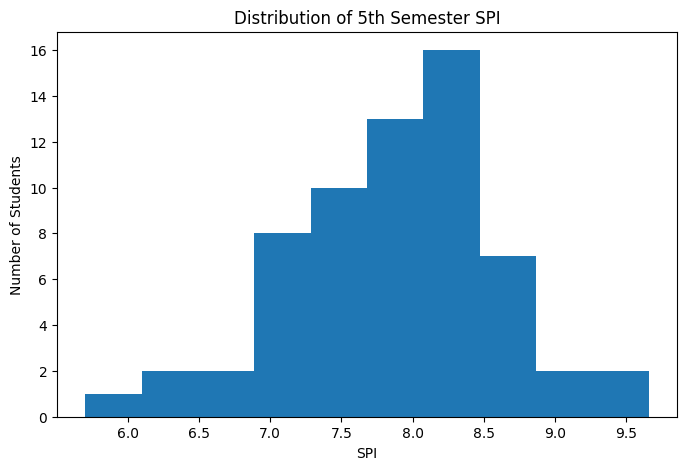

In [111]:
plt.figure(figsize=(8,5))

plt.hist(df["SPI - 5th Sem"])

plt.title("Distribution of 5th Semester SPI")

plt.xlabel("SPI")

plt.ylabel("Number of Students")

plt.show()

## SPI change analysis

In [112]:
df["SPI Change"] = df["SPI - 6th Sem"] - df["SPI - 5th Sem"]

In [113]:
df[["STUDENT NAME", "SPI - 5th Sem", "SPI - 6th Sem", "SPI Change"]].head()

,STUDENT NAME,SPI - 5th Sem,SPI - 6th Sem,SPI Change
0,Aarti Suryvanshi,7.66,7.60,-0.06
1,Aaryan lahre,NaN,NaN,NaN
2,Aaryansh Dwivedi,7.23,6.56,-0.67
3,Aayushman Dash,8.19,8.78,0.59
4,Abhinav Anand,7.23,7.52,0.29


In [114]:
df.sort_values(by="SPI Change", ascending=False).head(10)

,S.No,STUDENT NAME,ROLL NO,Gender,SPI - 1st Sem,SPI - 2nd Sem,SPI - 3rd Sem,SPI - 4th Sem,SPI - 5th Sem,SPI - 6th Sem,Attendance,Stay,SPI Change
17,18,D Rahul Chaitanya,23113025,Male,8.41,8.54,9.00,8.19,8.38,9.52,80,Hosteller,1.14
50,51,Milind Sen,23113061,Male,8.58,9.12,8.61,8.42,7.95,8.95,83,Hosteller,1.00
38,39,Pashmeen Kaur,23113048,Female,8.89,9.00,8.87,7.11,8.09,8.95,85,Hosteller,0.86
64,65,Kunwar Kaushlendra Pratap Singh,23113901,Male,9.37,9.25,7.50,8.38,8.23,9.08,85,Hosteller,0.85
32,33,Nirjala Jeeyalal,23113041,Female,7.45,7.79,6.88,7.46,7.52,8.34,90,Hosteller,0.82
49,50,SAURABH YADAV,23113060,Male,7.87,8.20,7.57,8.03,7.80,8.56,88,Hosteller,0.76
22,23,KEMBURU PRAVALIKA,23113031,Female,7.06,7.34,6.42,6.00,7.00,7.73,77,Hosteller,0.73
67,68,Neeraj Kumar Verma,23113904,Male,9.45,9.04,5.84,NaN,6.80,7.47,68,Hosteller,0.67
14,15,Ankita singh,23113018,Female,8.91,8.79,7.92,8.26,8.04,8.69,86,Hosteller,0.65
23,24,Kundan Kumar,23113032,Male,NaN,6.75,NaN,NaN,5.70,6.34,68,Day Scholar,0.64


In [115]:
df.sort_values(by="SPI Change").head(10)

,S.No,STUDENT NAME,ROLL NO,Gender,SPI - 1st Sem,SPI - 2nd Sem,SPI - 3rd Sem,SPI - 4th Sem,SPI - 5th Sem,SPI - 6th Sem,Attendance,Stay,SPI Change
15,16,Avik Mandal,23113020,Male,7.12,7.58,6.65,NaN,7.80,6.95,81,Hosteller,-0.85
33,34,Niyati Praveen Patodia,23113042,Female,8.56,8.87,8.42,8.30,8.42,7.73,85,Day Scholar,-0.69
63,64,Yansh Varsshnay,23113074,Male,8.91,9.00,8.34,8.84,8.76,8.08,86,Hosteller,-0.68
2,3,Aaryansh Dwivedi,23113003,Male,7.70,7.50,6.60,6.50,7.23,6.56,76,Day Scholar,-0.67
66,67,Naman Sharma,23113903,Male,9.25,9.33,7.92,8.54,8.61,8.00,75,Hosteller,-0.61
55,56,Sourabh Singh Chandel,23113066,Male,9.12,9.45,8.00,8.53,8.71,8.17,76,Hosteller,-0.54
30,31,Naman Jain,23113039,Male,9.58,9.00,9.34,9.19,8.23,7.69,88,Hosteller,-0.54
6,7,Adarsh Kumar,23113009,Male,8.08,7.95,7.53,NaN,6.95,6.47,60,Hosteller,-0.48
65,66,MULA VENKATA MAHESHWARA REDDY,23113902,Male,9.50,9.16,8.00,8.50,8.61,8.21,82,Hosteller,-0.40
34,35,Ojash Kumar Bhaladhare,23113043,Male,7.29,7.00,6.26,6.26,7.61,7.30,84,Day Scholar,-0.31


### The difference between average SPI in 6th sem and 5th Sem shows positive deviation

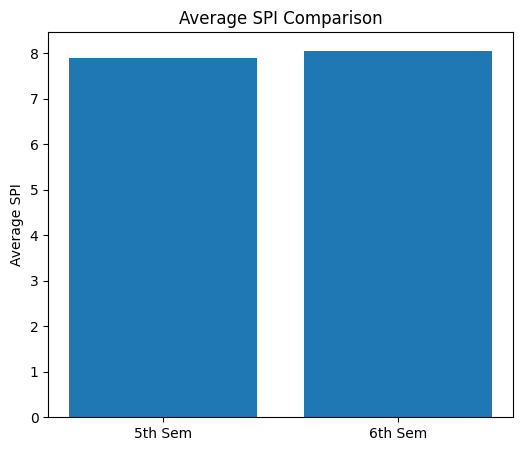

In [116]:
semester_avg = [
    df["SPI - 5th Sem"].mean(),
    df["SPI - 6th Sem"].mean()
]

semester_names = ["5th Sem", "6th Sem"]

plt.figure(figsize=(6,5))

plt.bar(semester_names, semester_avg)

plt.title("Average SPI Comparison")

plt.ylabel("Average SPI")

plt.show()

In [117]:
df["SPI Change"].mean()

np.float64(0.1480645161290323)

In [118]:
(df["SPI Change"] > 0).sum()

np.int64(39)

In [119]:
(df["SPI Change"] < 0).sum()

np.int64(23)

### This graph shows the distribution of SPI change from 5th sem to 6th sem

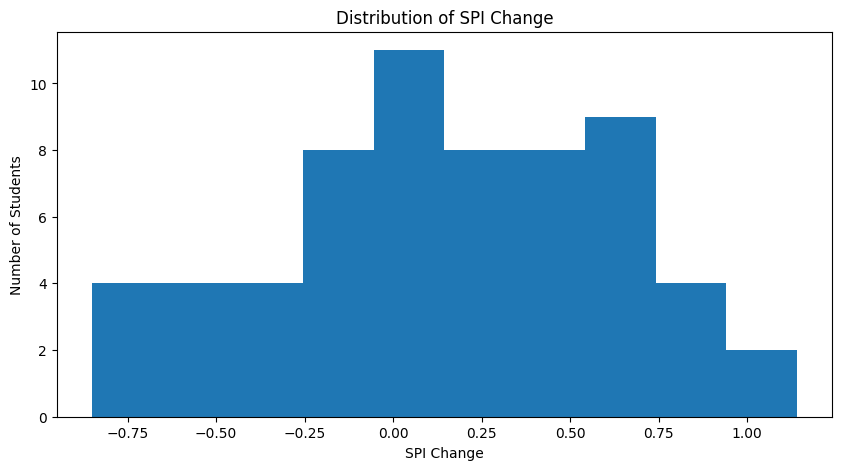

In [120]:
plt.figure(figsize=(10,5))

plt.hist(df["SPI Change"])

plt.title("Distribution of SPI Change")

plt.xlabel("SPI Change")

plt.ylabel("Number of Students")

plt.show()

#### A significant number of students improved their SPI from 5th to 6th semester.

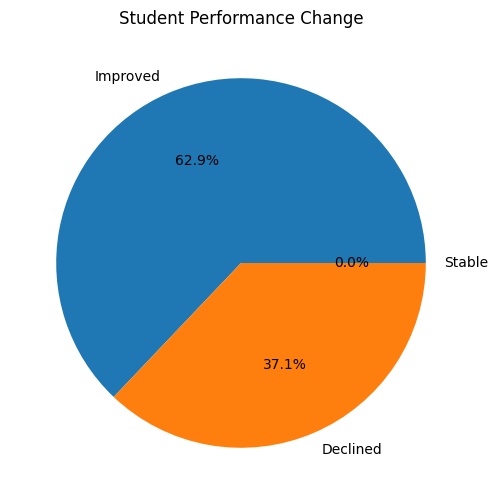

In [121]:
improved = (df["SPI Change"] > 0).sum()

declined = (df["SPI Change"] < 0).sum()

stable = (df["SPI Change"] == 0).sum()

labels = ["Improved", "Declined", "Stable"]

values = [improved, declined, stable]

plt.figure(figsize=(6,6))

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Student Performance Change")

plt.show()

### Consistency Analysis 

This analysis identifies students whose academic performance remained relatively stable between the 5th and 6th semesters.
Students with an SPI change of less than 0.2 were classified as consistent performers.


In [122]:
abs(df["SPI Change"]) < 0.2

0      True
1     False
2     False
3     False
4     False
      ...  
64    False
65    False
66    False
67    False
68     True
Name: SPI Change, Length: 69, dtype: bool

In [123]:
consistent_students = (abs(df["SPI Change"]) < 0.2).sum()

consistent_students

np.int64(21)

In [124]:
df[abs(df["SPI Change"]) < 0.2][["STUDENT NAME", "SPI - 5th Sem", "SPI - 6th Sem", "SPI Change"]]

,STUDENT NAME,SPI - 5th Sem,SPI - 6th Sem,SPI Change
0,Aarti Suryvanshi,7.66,7.60,-0.06
5,Abhishek Kumar Singh,8.33,8.26,-0.07
8,Adigarla Varshini,9.52,9.34,-0.18
10,Ajit Kumar,8.23,8.30,0.07
16,Bhuvnesh Arela,8.19,8.08,-0.11
18,Tanish Dhavale,8.52,8.34,-0.18
19,Disha Deoghare,8.04,7.86,-0.18
20,G Diwakar Reddy,7.80,7.86,0.06
21,HARSH KUMAR SARVA,7.57,7.43,-0.14
26,Madhavi dewangan,9.66,9.78,0.12


## Performance Categorization

In [125]:
def performance_category(spi):

    if spi >= 9:
        return "Excellent"
    
    elif spi >= 8:
        return "Good"
    
    elif spi >= 7:
        return "Average"
    
    else:
        return "Needs Improvement"

In [126]:
df["Performance Category"] = df["SPI - 5th Sem"].apply(performance_category)

In [127]:
df[["STUDENT NAME", "SPI - 5th Sem", "Performance Category"]].head(10)

,STUDENT NAME,SPI - 5th Sem,Performance Category
0,Aarti Suryvanshi,7.66,Average
1,Aaryan lahre,NaN,Needs Improvement
2,Aaryansh Dwivedi,7.23,Average
3,Aayushman Dash,8.19,Good
4,Abhinav Anand,7.23,Average
5,Abhishek Kumar Singh,8.33,Good
6,Adarsh Kumar,6.95,Needs Improvement
7,Adiba Tazmeen,9.09,Excellent
8,Adigarla Varshini,9.52,Excellent
9,Aditya Gupta,8.61,Good


In [128]:
df["Performance Category"].value_counts()

Performance Category
Average              28
Good                 25
Needs Improvement    12
Excellent             4
Name: count, dtype: int64

### This graph gives the distribution of Students according to performance Categories

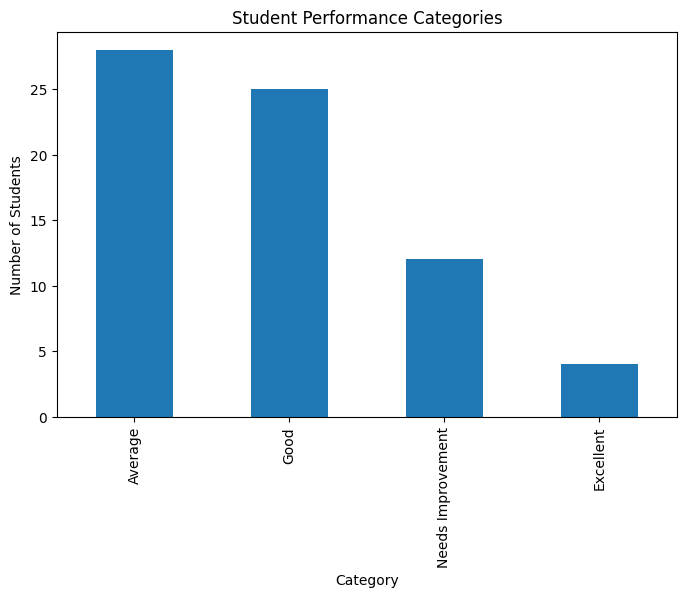

In [129]:
plt.figure(figsize=(8,5))

df["Performance Category"].value_counts().plot(kind="bar")

plt.title("Student Performance Categories")

plt.xlabel("Category")

plt.ylabel("Number of Students")

plt.show()

#### Most students fall within the average-to-good SPI range, indicating stable overall academic performance.

## Attendance Analysis

### This analysis helps identify whether attendance affects academic performance.

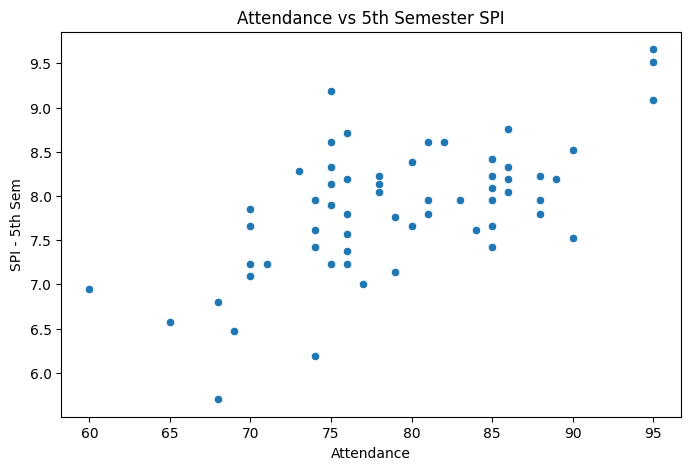

In [130]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Attendance", y="SPI - 5th Sem", data=df)

plt.title("Attendance vs 5th Semester SPI")

plt.show()

In [131]:
df[["Attendance", "SPI - 5th Sem"]].corr()

,Attendance,SPI - 5th Sem
Attendance,1.00000,0.64521
SPI - 5th Sem,0.64521,1.00000


In [132]:
df.groupby("Stay")["SPI - 5th Sem"].mean()

Stay
Day Scholar    7.418750
Hosteller      8.055957
Name: SPI - 5th Sem, dtype: float64

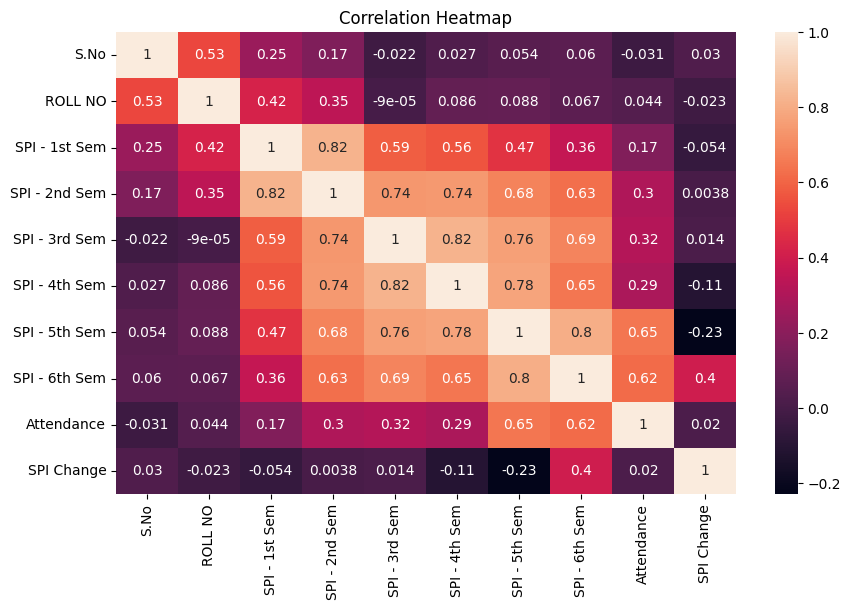

In [133]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

### Insight
- Most students with higher attendance tend to have better SPI values.
- Students with low attendance are more likely to have lower academic performance.
- A positive correlation was observed between attendance and SPI, indicating that attendance has a meaningful impact on academic outcomes.
- However, a few exceptions are present where students achieved good SPI despite lower attendance, showing that attendance is not the only factor affecting performance.


## Gender Analysis

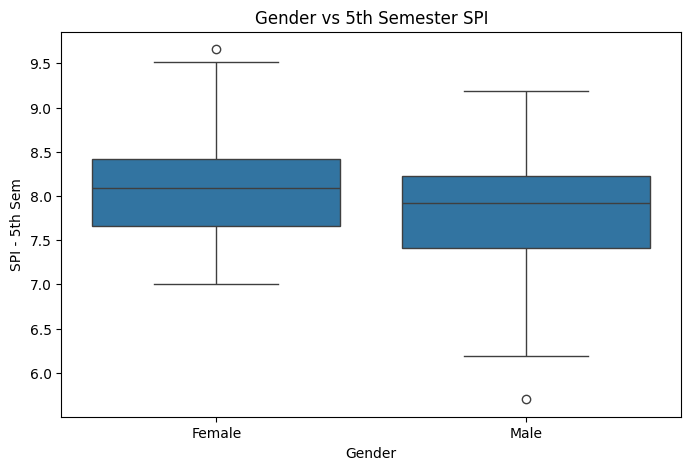

In [134]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Gender", y="SPI - 5th Sem", data=df)

plt.title("Gender vs 5th Semester SPI")

plt.show()

### Insight
The gender-wise analysis indicates that there is no major performance gap between male and female students. Both groups demonstrate similar academic trends and performance levels. The results suggest that gender does not significantly affect academic outcomes within the class dataset.

## Accomodation Analysis

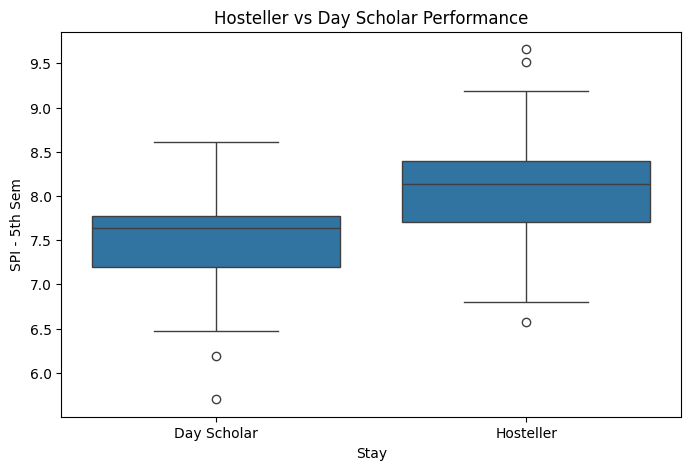

In [135]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Stay", y="SPI - 5th Sem", data=df)

plt.title("Hosteller vs Day Scholar Performance")

plt.show()

### Insight

- Hostellers show a slightly higher median SPI compared to Day Scholars, indicating marginally better average academic performance.
- The SPI distribution among Hostellers is wider, suggesting greater variation in student performance levels.
- Day Scholars exhibit relatively more consistent performance with a narrower spread of SPI values.

## Backlog/Due Credit Analysis

In [136]:
backlogs = df.isnull().sum()

backlogs

S.No                     0
STUDENT NAME             0
ROLL NO                  0
Gender                   0
SPI - 1st Sem            1
SPI - 2nd Sem            0
SPI - 3rd Sem            3
SPI - 4th Sem           13
SPI - 5th Sem            6
SPI - 6th Sem            6
Attendance               0
Stay                     0
SPI Change               7
Performance Category     0
dtype: int64

In [137]:
spi_backlogs = backlogs[
    ["SPI - 1st Sem",
     "SPI - 2nd Sem",
     "SPI - 3rd Sem",
     "SPI - 4th Sem",
     "SPI - 5th Sem",
     "SPI - 6th Sem"]
]

spi_backlogs

SPI - 1st Sem     1
SPI - 2nd Sem     0
SPI - 3rd Sem     3
SPI - 4th Sem    13
SPI - 5th Sem     6
SPI - 6th Sem     6
dtype: int64

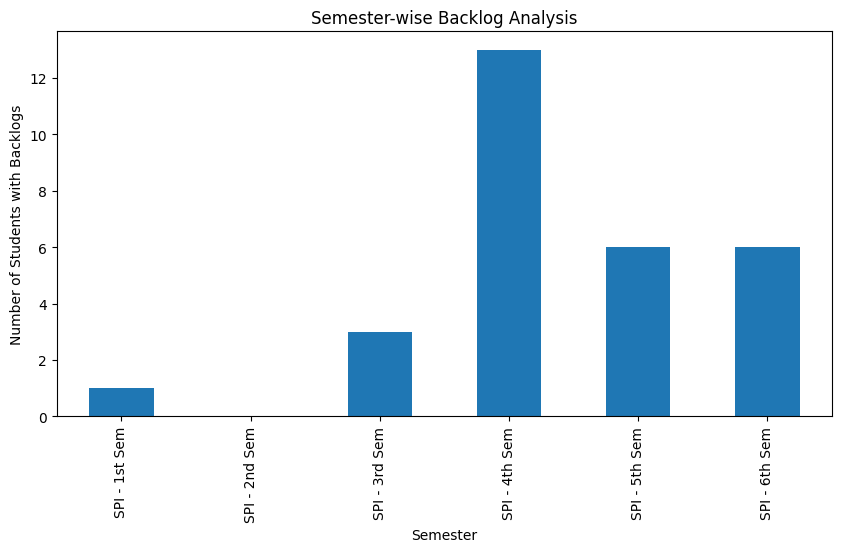

In [138]:
plt.figure(figsize=(10,5))

spi_backlogs.plot(kind="bar")

plt.title("Semester-wise Backlog Analysis")

plt.xlabel("Semester")

plt.ylabel("Number of Students with Backlogs")

plt.show()

In [139]:
spi_backlogs.idxmax()

'SPI - 4th Sem'

In [141]:
students_with_backlogs = df[df.isnull().any(axis=1)]

In [142]:
students_with_backlogs[["STUDENT NAME", "ROLL NO"]]

,STUDENT NAME,ROLL NO
1,Aaryan lahre,23113002
4,Abhinav Anand,23113006
6,Adarsh Kumar,23113009
13,Aniket Dhruw,23113017
15,Avik Mandal,23113020
20,G Diwakar Reddy,23113028
23,Kundan Kumar,23113032
25,Laxmikant Sidar,23113034
28,Mohit Vishwakarma,23113037
29,Nairitya Kumar Sahu,23113038


#### Insight

- Total Students with Backlogs: 15
- Semester with Highest Backlogs: 4th Semester
- Majority of Students Maintained Continuous Academic Progress